In [ ]:
from pathlib import Path
from imd_features.config import FeatureSetConfig, GroupConfig, ReductionMethod
from imd_features.process import create_feature_set
from imd_features.diagnostic import (
    group_summary,
    correlation_within_groups,
    correlation_between_groups,
    correlation_full,
    distribution_plot,
)
import polars as pl
from project_paths import paths


In [2]:

output_dir = paths.output

config_path = output_dir / "mixed_reduction_b78f17cd_config.json" 
config = FeatureSetConfig.model_validate_json(config_path.read_text())

df = pl.read_parquet(output_dir / f"{config.output_name}.parquet")
metadata = {}  # not available when loading from disk


In [3]:
df.describe()

statistic,lsoa_code,violent-crime,burglary,anti-social-behaviour,shoplifting,criminal-damage-arson,drugs,robbery,vehicle-crime,other-theft,public-order,bicycle-theft,other-crime,theft-from-the-person,total_crimes,resolution_rate,total_claims,mean_monthly_claims,total_nwr_claims,total_planfw_claims,total_prepfw_claims,total_sfw_claims,%_claims_nwr,%_claims_planfw,%_claims_prepfw,%_claims_sfw,connectivity_factor_analysis_1,connectivity_factor_analysis_2,connectivity_factor_analysis_3,connectivity_factor_analysis_4,lsoa_average_price,lsoa_max_price,T_mean_price,F_mean_price,S_mean_price,D_mean_price,…,osm_amenities_pca_12,osm_amenities_pca_13,osm_amenities_pca_14,osm_amenities_pca_15,landuse_allotments_0,landuse_brownfield_0,landuse_cemetery_0,landuse_commercial_0,landuse_conservation_0,landuse_construction_0,landuse_depot_0,landuse_education_0,landuse_farmland_0,landuse_farmyard_0,landuse_flowerbed_0,landuse_garages_0,landuse_grass_0,landuse_greenfield_0,landuse_greenhouse_horticulture_0,landuse_industrial_0,landuse_landfill_0,landuse_meadow_0,landuse_military_0,landuse_orchard_0,landuse_plant_nursery_0,landuse_railway_0,landuse_recreation_ground_0,landuse_religious_0,landuse_residential_0,landuse_retail_0,landuse_storage_0,landuse_terminal_0,streetlit_percentage,lsoa_population,aged_under_15,working_age_population,pension_age_population
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""268""",268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,…,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0,268.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,1.3256e-17,-3.9769e-17,-1.3256e-17,1.6570e-17,-3.9769e-17,-2.6513e-17,1.3256e-17,-1.9885e-17,-1.6570e-17,0.0,-6.9596e-17,3.9769e-17,-1.4913e-17,2.6513e-17,9.0143e-16,-9.9423e-17,5.9654e-17,-9.9423e-17,-9.9423e-17,-9.9423e-17,-9.9423e-17,0.0,0.0,0.0,0.0,-3.4732e-15,1.1931e-16,3.3141e-17,4.5072e-16,1.3919e-16,1.4913e-17,-2.6513e-17,1.0605e-16,-7.2910e-17,-7.2910e-17,…,2.6513e-17,-1.0605e-16,-1.3256e-16,1.5908e-16,2.3199e-17,-2.8170e-17,4.4740e-17,-1.9885e-17,1.2842e-17,-4.9711e-18,1.6570e-18,-4.9711e-18,-4.1426e-17,-1.6570e-17,-2.2370e-17,2.4027e-17,9.9423e-18,-4.1426e-19,1.2842e-17,1.6570e-17,1.6156e-17,-4.9711e-18,2.8998e-17,-2.4856e-18,1.2842e-17,6.4625e-17,-7.6224e-17,2.4856e-18,-2.2536e-16,3.3141e-18,1.2842e-17,-1.2428e-18,-8.6167e-17,0.0,-2.6513e-17,-1.4582e-16,3.9769e-17
"""std""",null,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,0.0,0.0,0.0,0.0,0.997313,1.001673,1.00129,0.992544,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,…,1.364663,1.351136,1.314982,1.273218,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871,1.001871
"""min""","""E01014485""",-1.022558,-1.108535,-0.681682,-0.398099,-1.053593,-0.736341,-0.541922,-1.291883,-0.665294,-0.69527,-

In [4]:
group_summary(config, metadata)

group,input_features,output_features,scaled,reduction
str,i64,i64,bool,str
"""crime""",15,15,true,"""none"""
"""universal_credit""",10,10,true,"""none"""
"""connectivity""",35,4,true,"""factor_analysis"""
"""land_registry""",13,13,true,"""none"""
"""osm_amenities""",222,15,true,"""pca"""
"""osm_landuse""",29,29,true,"""none"""
"""population""",4,4,true,"""none"""


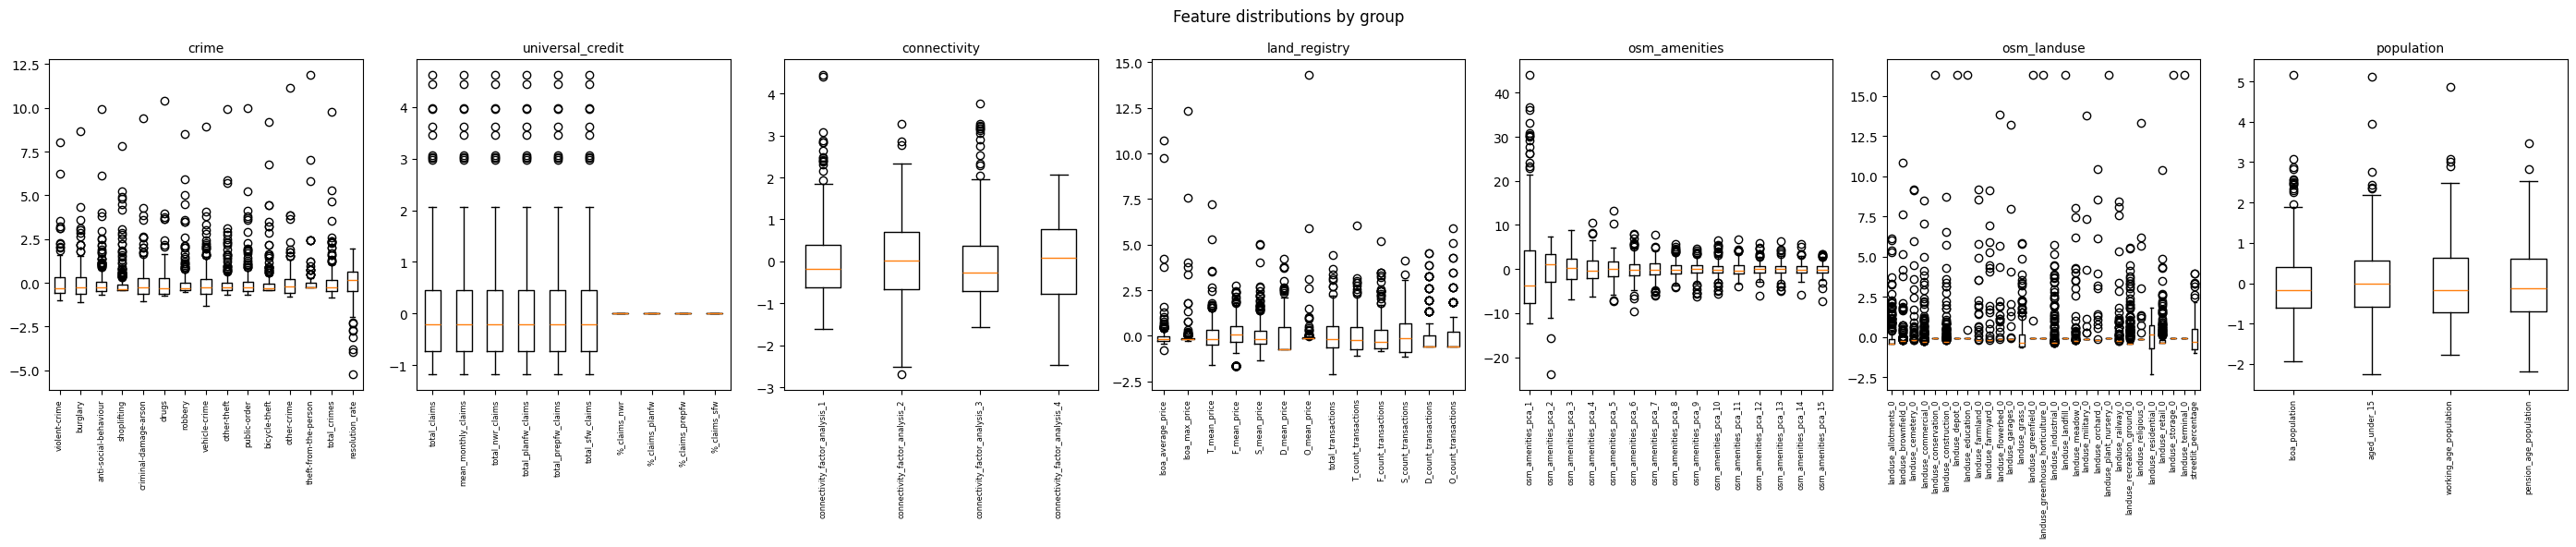

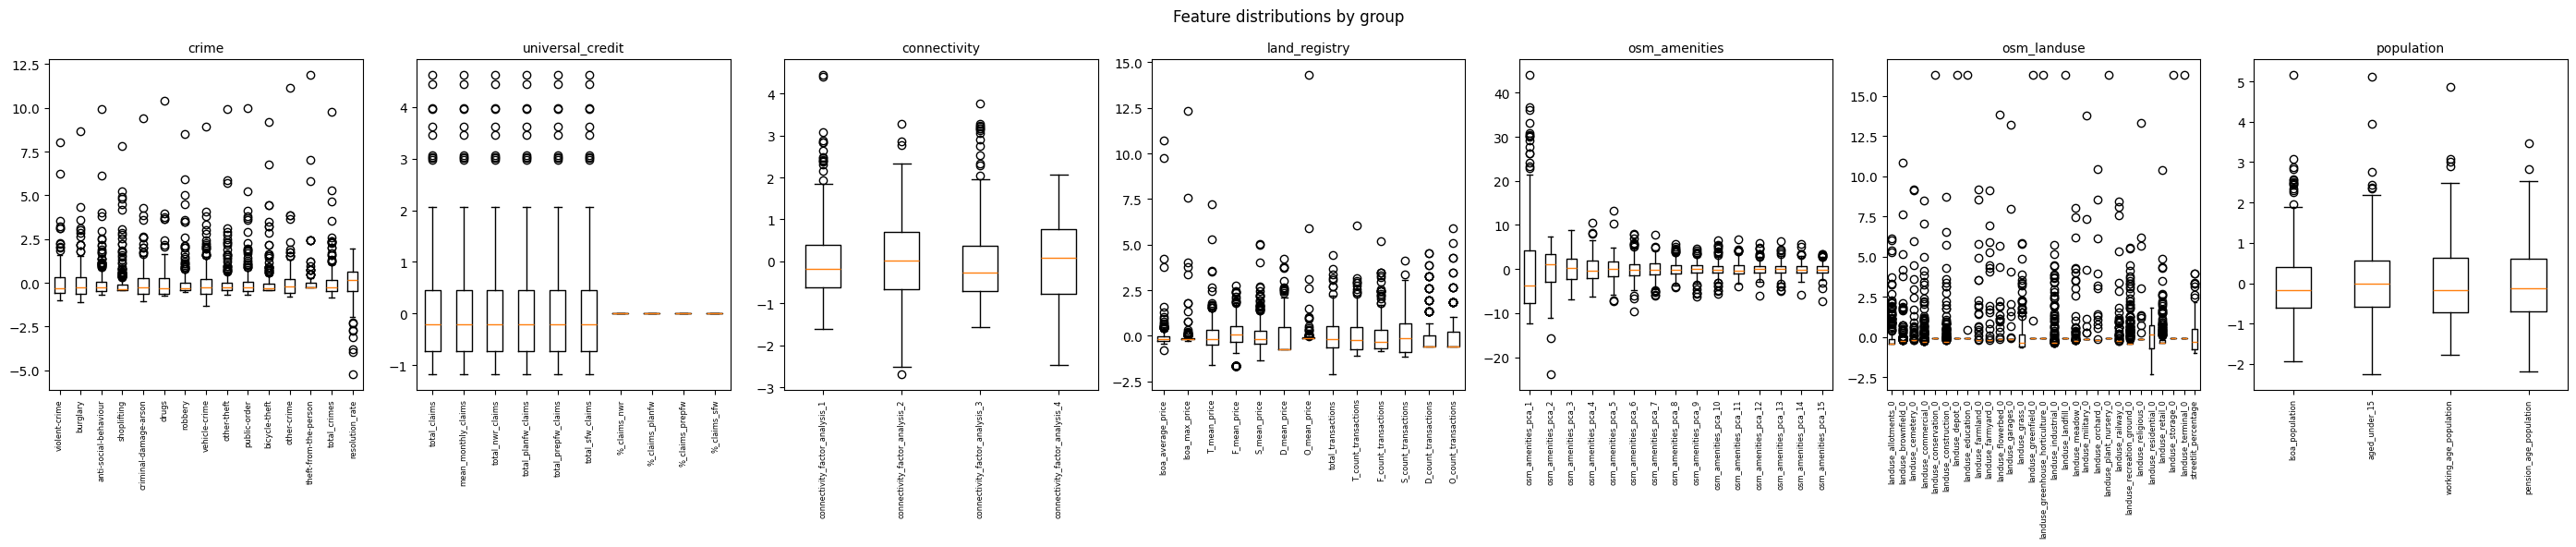

In [5]:
distribution_plot(df, config)

c:\Users\Daniel\projects\imd_feature_engineering\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Daniel\projects\imd_feature_engineering\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\Daniel\AppData\Local\Temp\ipykernel_26576\1389867195.py:3: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


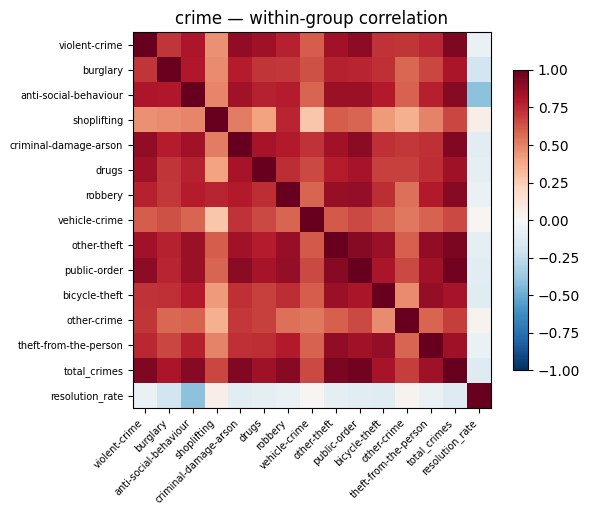

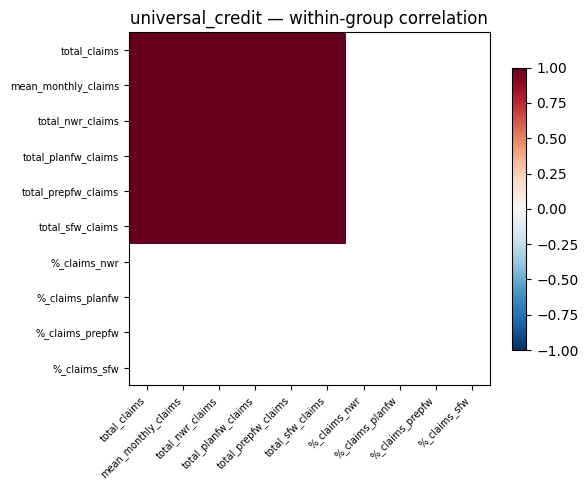

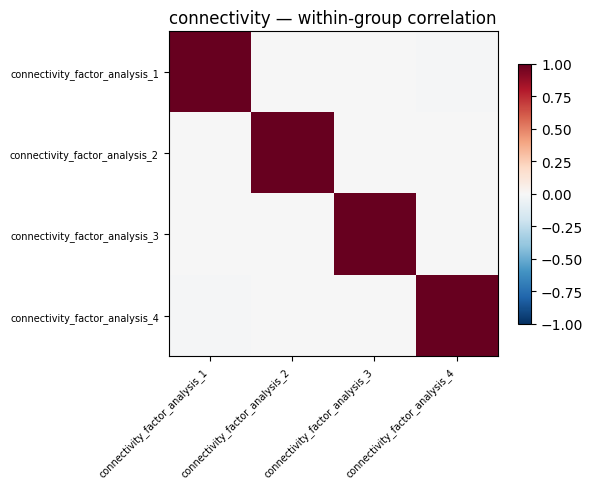

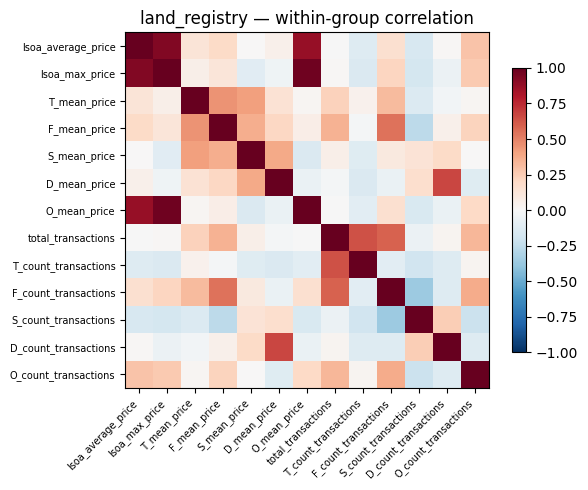

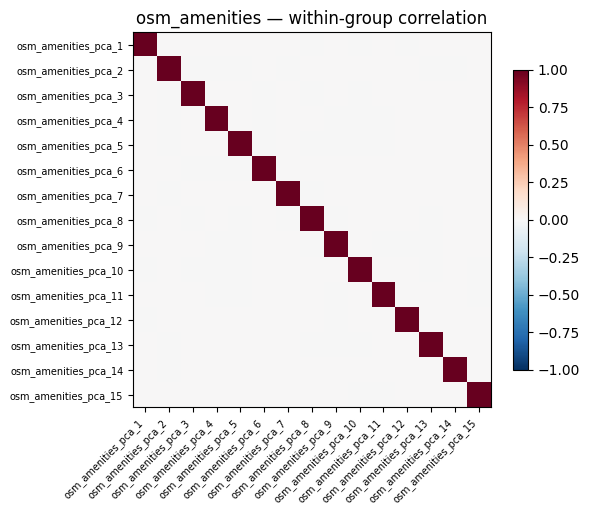

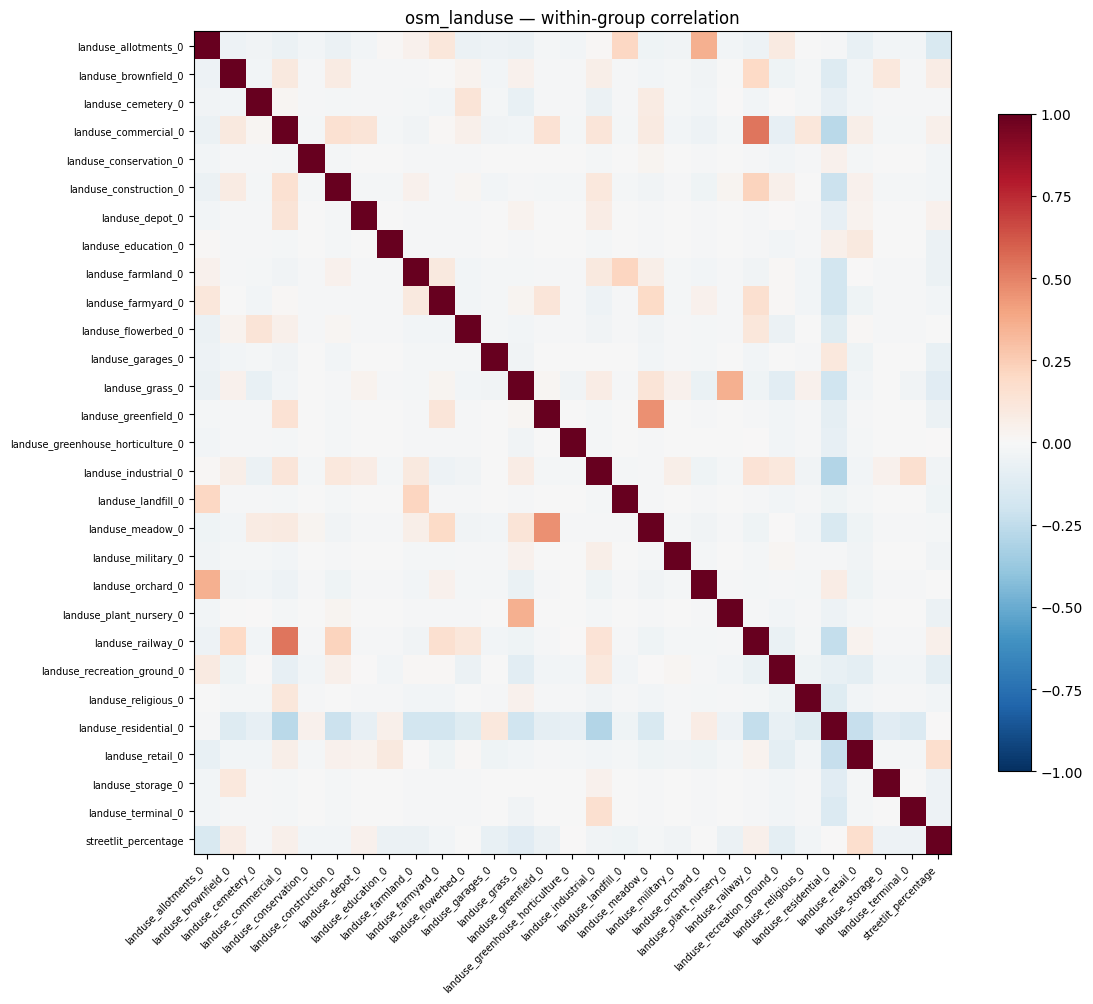

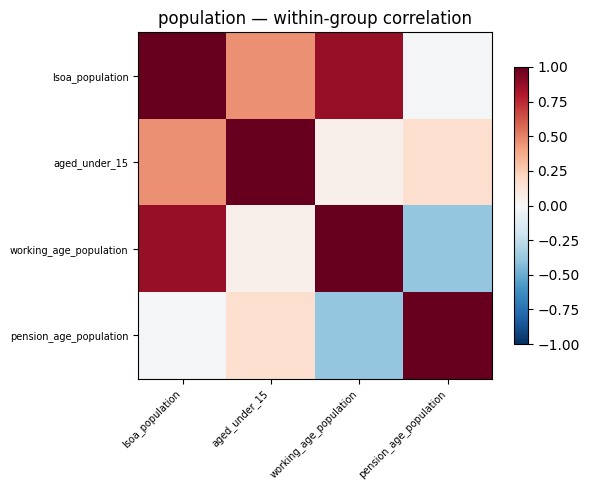

In [6]:
within_corrs = correlation_within_groups(df, config)
for name, fig in within_corrs.items():
    fig.show()

c:\Users\Daniel\projects\imd_feature_engineering\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Daniel\projects\imd_feature_engineering\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


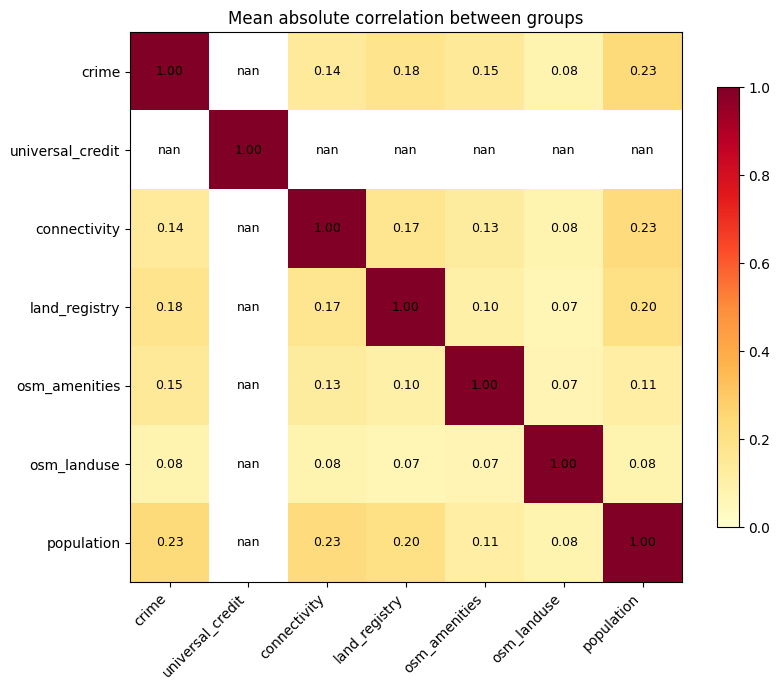

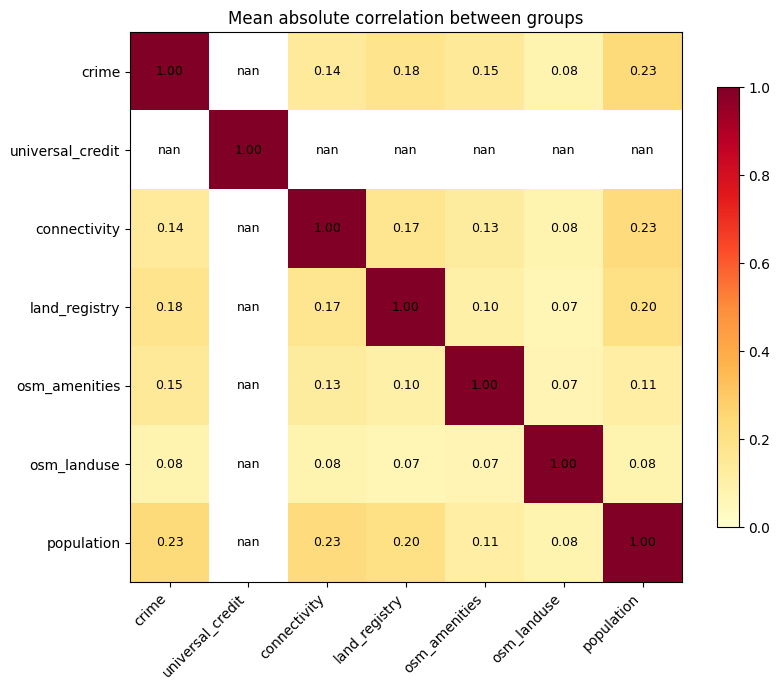

In [7]:
correlation_between_groups(df, config)

c:\Users\Daniel\projects\imd_feature_engineering\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Daniel\projects\imd_feature_engineering\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


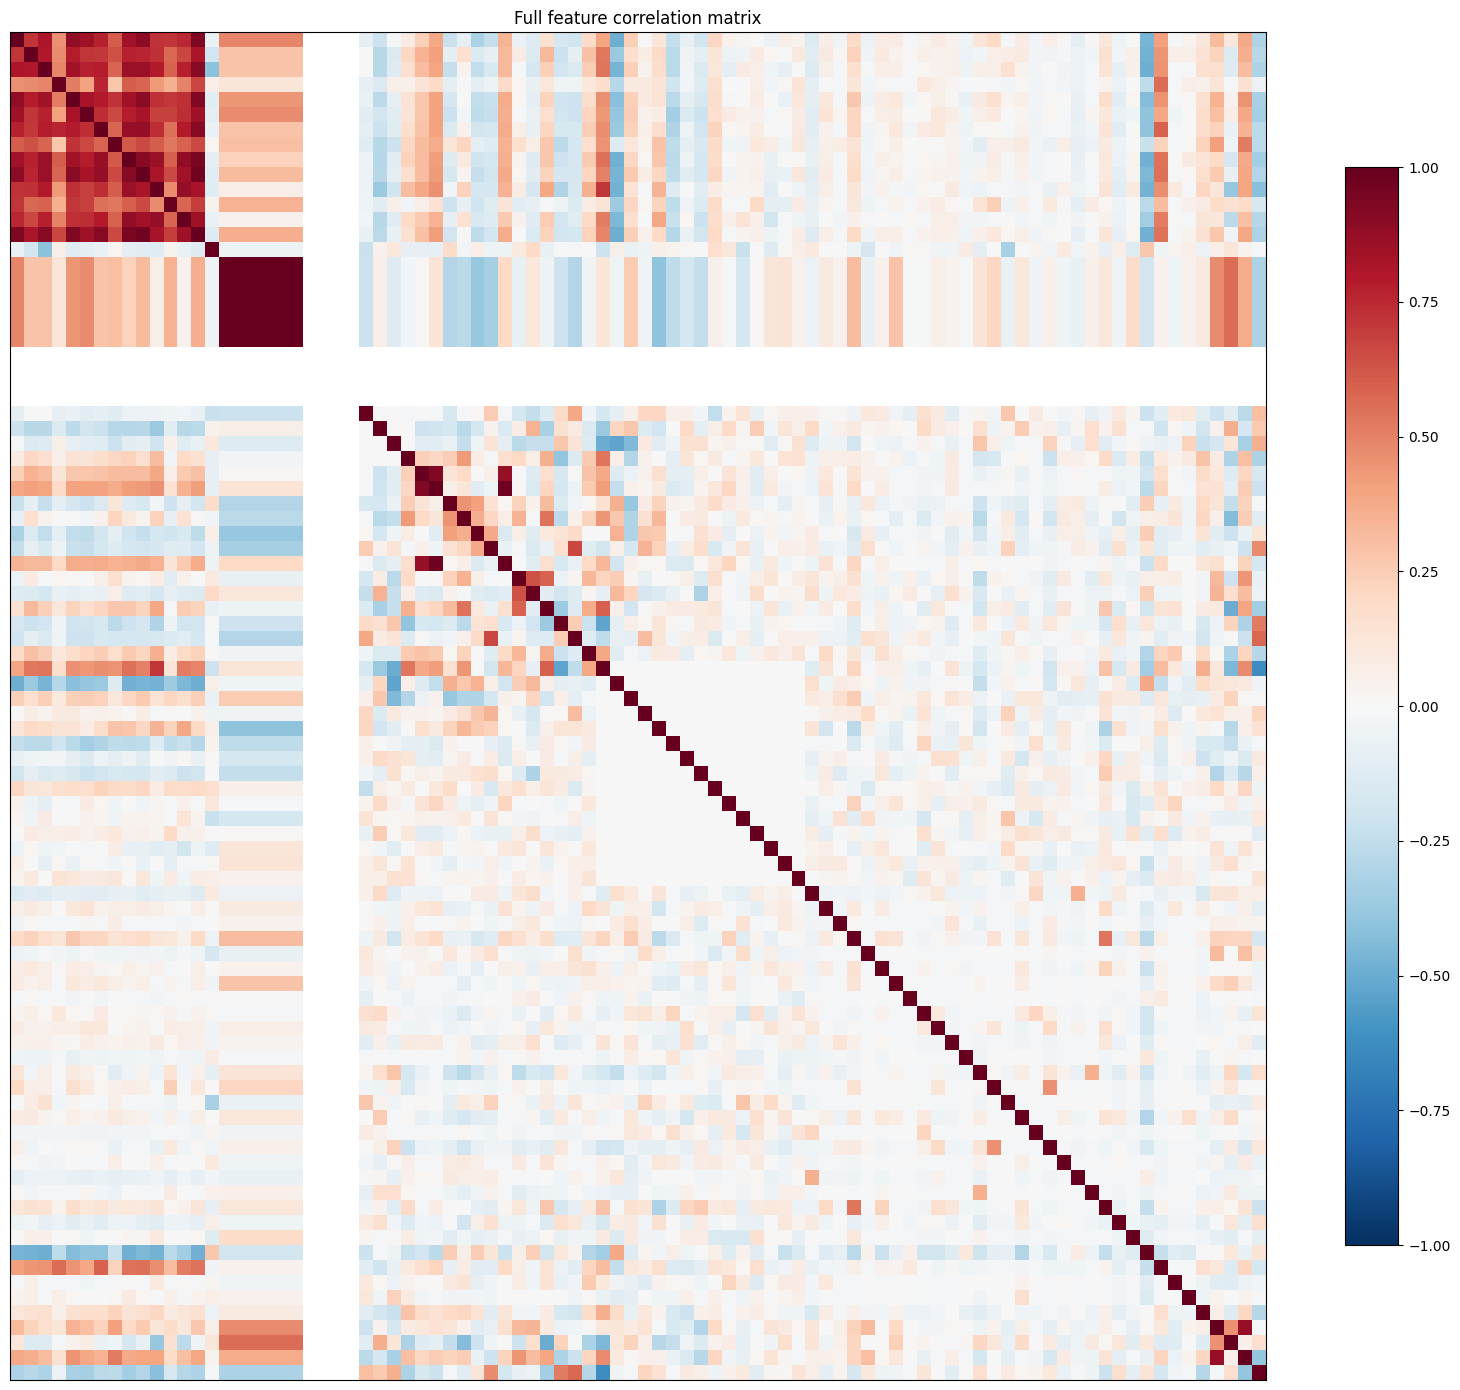

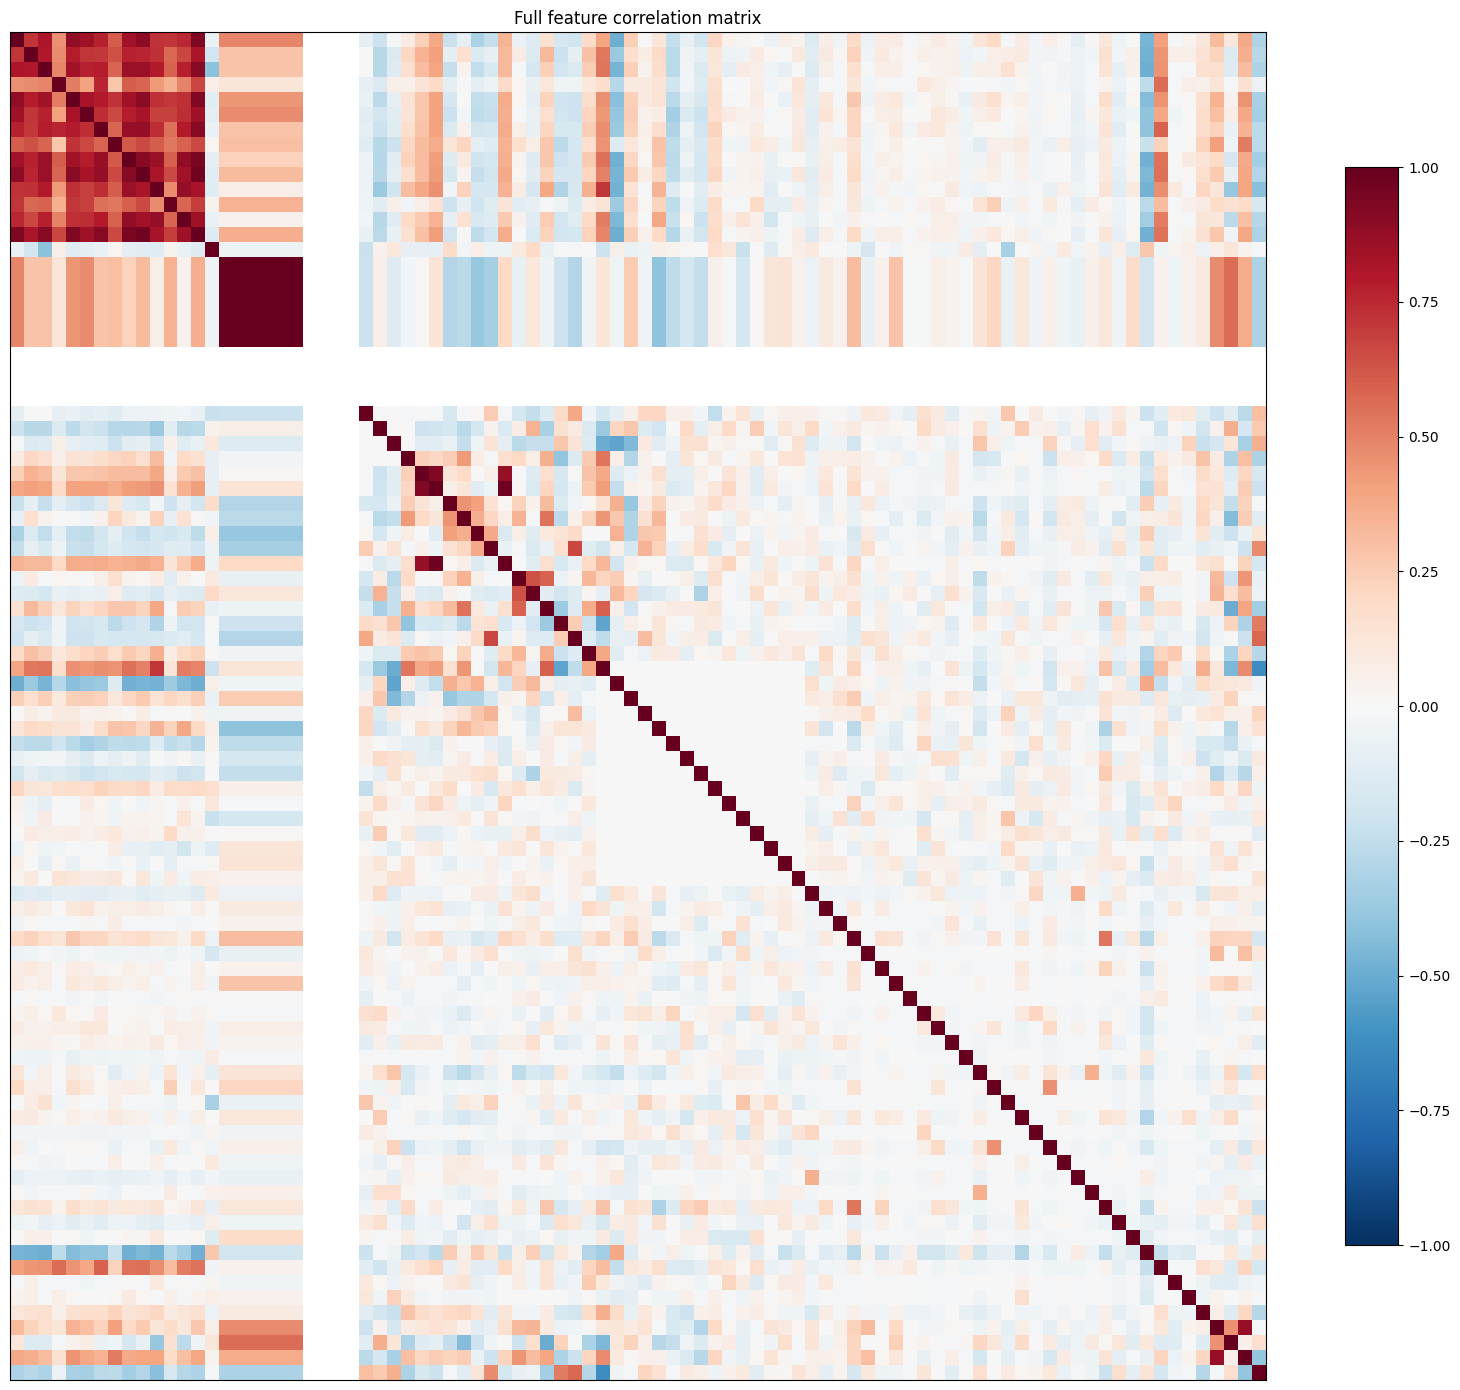

In [8]:
correlation_full(df)